# 01 · Exploratory data analysis (HI-Small)
Scale, class balance, laundering rates, amounts, time profile and typologies.
Figures are written to `reports/figures/`. Aggregation is done in DuckDB.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aml.config import load_config

cfg = load_config()
FIG = cfg.root / cfg.paths.figures_dir
TAB = cfg.root / cfg.paths.tables_dir
P = cfg.transactions_parquet.as_posix()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
LICIT, ILLICIT = "#4C72B0", "#C44E52"
q = lambda sql: duckdb.sql(sql).df()

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    plt.show()

## Scale of the data

In [2]:
scale = q(f"""
    SELECT (SELECT count(*) FROM '{P}') AS transactions,
           (SELECT count(*) FROM (SELECT src FROM '{P}' UNION SELECT dst FROM '{P}')) AS accounts,
           (SELECT count(*) FROM (SELECT from_bank FROM '{P}' UNION SELECT to_bank FROM '{P}')) AS banks,
           (SELECT min(timestamp) FROM '{P}') AS first_ts, (SELECT max(timestamp) FROM '{P}') AS last_ts
""")
scale["span_days"] = (scale.last_ts - scale.first_ts).dt.total_seconds() / 86400
scale.to_csv(TAB / "eda_scale.csv", index=False)
scale.T

,0
transactions,5078345
accounts,515088
banks,30528
first_ts,2022-09-01 00:00:00
last_ts,2022-09-18 16:18:00
span_days,17.679167


## Class balance

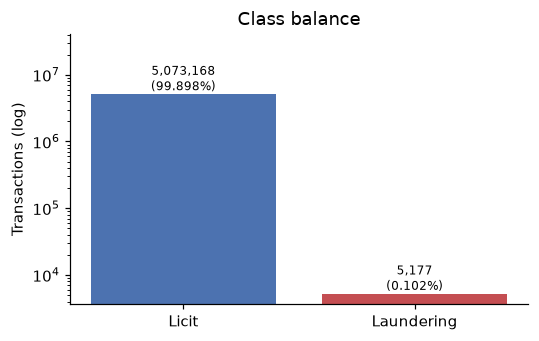

,is_laundering,n,share_pct
0,0,5073168,99.898057
1,1,5177,0.101943


In [3]:
bal = q(f"SELECT is_laundering, count(*) AS n FROM '{P}' GROUP BY 1 ORDER BY 1")
bal["share_pct"] = 100 * bal.n / bal.n.sum()
bal.to_csv(TAB / "eda_class_balance.csv", index=False)
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["Licit", "Laundering"], bal.n, color=[LICIT, ILLICIT])
ax.set_yscale("log"); ax.set_ylabel("Transactions (log)")
for i, r in bal.iterrows():
    ax.text(i, r.n, f"{int(r.n):,}\n({r.share_pct:.3f}%)", ha="center", va="bottom", fontsize=8)
ax.set_ylim(top=bal.n.max() * 8); ax.set_title("Class balance")
save(fig, "eda_class_balance")
bal

## Laundering rate by payment format and by currency

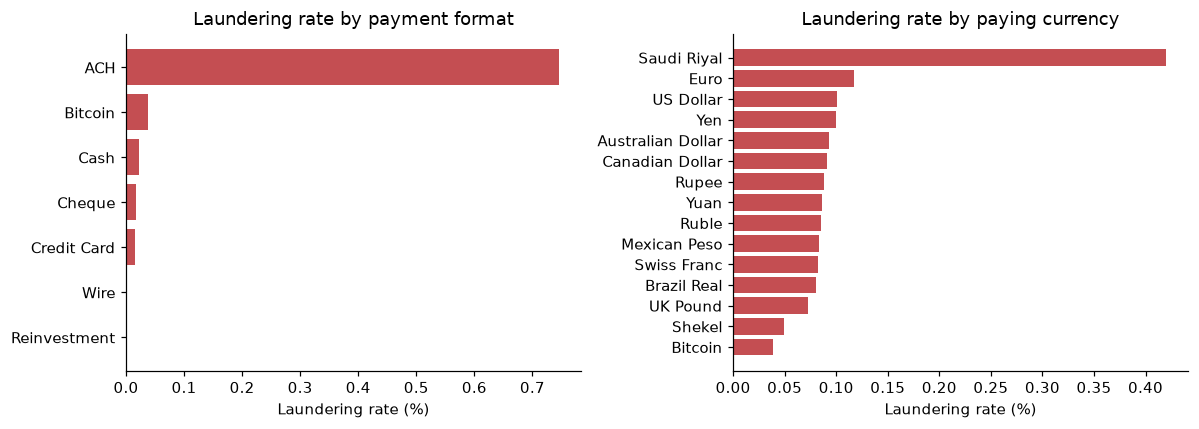

,grp,n,ill,rate_pct
0,ACH,600797,4483.0,0.746175
1,Bitcoin,146091,56.0,0.038332
2,Cash,490891,108.0,0.022001
3,Cheque,1864331,324.0,0.017379
4,Credit Card,1323324,206.0,0.015567
5,Wire,171855,0.0,0.000000
6,Reinvestment,481056,0.0,0.000000


,grp,n,ill,rate_pct
0,Saudi Riyal,89014,374.0,0.420159
1,Euro,1168297,1372.0,0.117436
2,US Dollar,1895172,1912.0,0.100888
3,Yen,155209,155.0,0.099865
4,Australian Dollar,136769,127.0,0.092857
5,Canadian Dollar,140042,128.0,0.091401
6,Rupee,190202,167.0,0.087801
7,Yuan,213752,184.0,0.086081
8,Ruble,155178,133.0,0.085708
9,Mexican Peso,110159,92.0,0.083516


In [4]:
by_fmt = q(f"""SELECT payment_format AS grp, count(*) n, sum(is_laundering) ill,
               100.0*avg(is_laundering) AS rate_pct FROM '{P}' GROUP BY 1 ORDER BY rate_pct DESC""")
by_ccy = q(f"""SELECT pay_ccy AS grp, count(*) n, sum(is_laundering) ill,
               100.0*avg(is_laundering) AS rate_pct FROM '{P}' GROUP BY 1 ORDER BY rate_pct DESC""")
by_fmt.to_csv(TAB / "eda_rate_by_format.csv", index=False)
by_ccy.to_csv(TAB / "eda_rate_by_currency.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d, t in zip(axes, (by_fmt, by_ccy), ("payment format", "paying currency")):
    ax.barh(d.grp[::-1], d.rate_pct[::-1], color=ILLICIT)
    ax.set_xlabel("Laundering rate (%)"); ax.set_title(f"Laundering rate by {t}")
save(fig, "eda_rate_by_format_currency")
display(by_fmt); display(by_ccy)

## Cross-currency share, licit vs illicit
Note: cross-currency transactions are rare and, in HI-Small, never laundering.

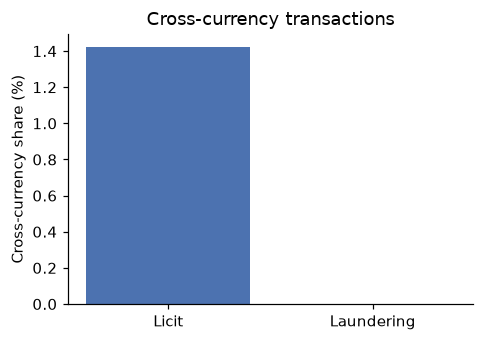

,is_laundering,n,xc,xc_pct
0,0,5073168,72170.0,1.422582
1,1,5177,0.0,0.000000


In [5]:
xc = q(f"""SELECT is_laundering, count(*) n, sum((pay_ccy<>recv_ccy)::INT) xc,
           100.0*avg((pay_ccy<>recv_ccy)::INT) AS xc_pct FROM '{P}' GROUP BY 1 ORDER BY 1""")
xc.to_csv(TAB / "eda_cross_currency.csv", index=False)
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.bar(["Licit", "Laundering"], xc.xc_pct, color=[LICIT, ILLICIT])
ax.set_ylabel("Cross-currency share (%)"); ax.set_title("Cross-currency transactions")
save(fig, "eda_cross_currency")
xc

## Amount distributions (USD, log scale)

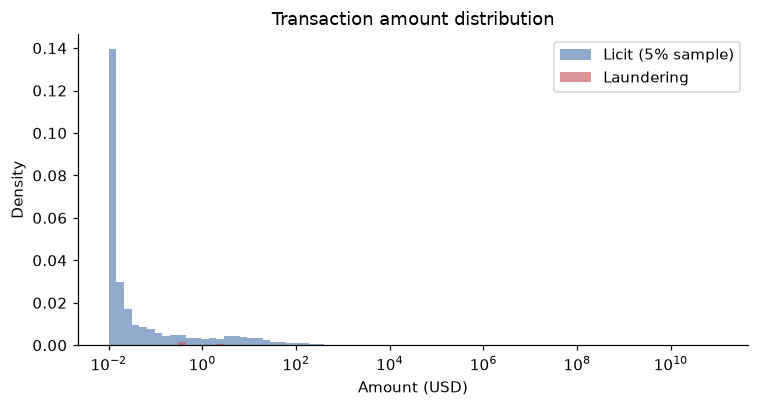

,count,mean,std,min,25%,50%,75%,99%,max
is_laundering,,,,,,,,,
0,253791.0,3.549676e+05,1.863876e+07,0.000095,157.461187,893.579928,5296.938245,3.072765e+06,7.161724e+09
1,5177.0,5.169485e+06,2.313315e+08,0.386689,2160.560000,5878.806939,13758.502842,1.579320e+07,1.629705e+10


In [6]:
amt = q(f"""SELECT is_laundering, amt_usd FROM '{P}' WHERE amt_usd > 0
            AND (is_laundering = 1 OR random() < 0.05)""")
bins = np.logspace(-2, 11, 80)
fig, ax = plt.subplots(figsize=(7, 3.8))
for lab, col, name in ((0, LICIT, "Licit (5% sample)"), (1, ILLICIT, "Laundering")):
    ax.hist(amt.loc[amt.is_laundering == lab, "amt_usd"], bins=bins, density=True,
            alpha=0.6, color=col, label=name)
ax.set_xscale("log"); ax.set_xlabel("Amount (USD)"); ax.set_ylabel("Density")
ax.legend(); ax.set_title("Transaction amount distribution")
save(fig, "eda_amount_distribution")
amt.groupby("is_laundering").amt_usd.describe(percentiles=[.25, .5, .75, .99])

## Round amounts
A round amount here is a multiple of 100 in the paying currency.

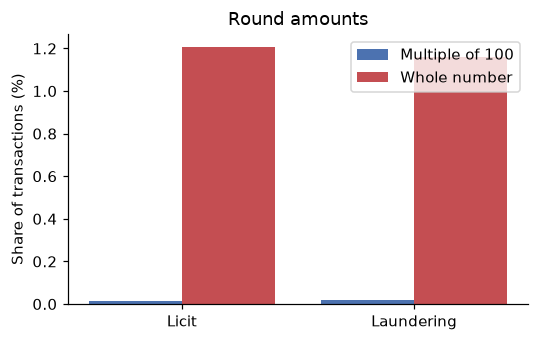

,is_laundering,round_pct,whole_pct
0,0,0.012339,1.206682
1,1,0.019316,1.158972


In [7]:
rnd = q(f"""SELECT is_laundering, 100.0*avg((amt_paid % 100 = 0)::INT) AS round_pct,
            100.0*avg((amt_paid % 1 = 0)::INT) AS whole_pct FROM '{P}' GROUP BY 1 ORDER BY 1""")
rnd.to_csv(TAB / "eda_round_amounts.csv", index=False)
fig, ax = plt.subplots(figsize=(5, 3.2))
x = np.arange(2)
ax.bar(x - 0.2, rnd.round_pct, 0.4, label="Multiple of 100", color=LICIT)
ax.bar(x + 0.2, rnd.whole_pct, 0.4, label="Whole number", color=ILLICIT)
ax.set_xticks(x, ["Licit", "Laundering"]); ax.set_ylabel("Share of transactions (%)")
ax.legend(); ax.set_title("Round amounts")
save(fig, "eda_round_amounts")
rnd

## Activity and laundering rate over time

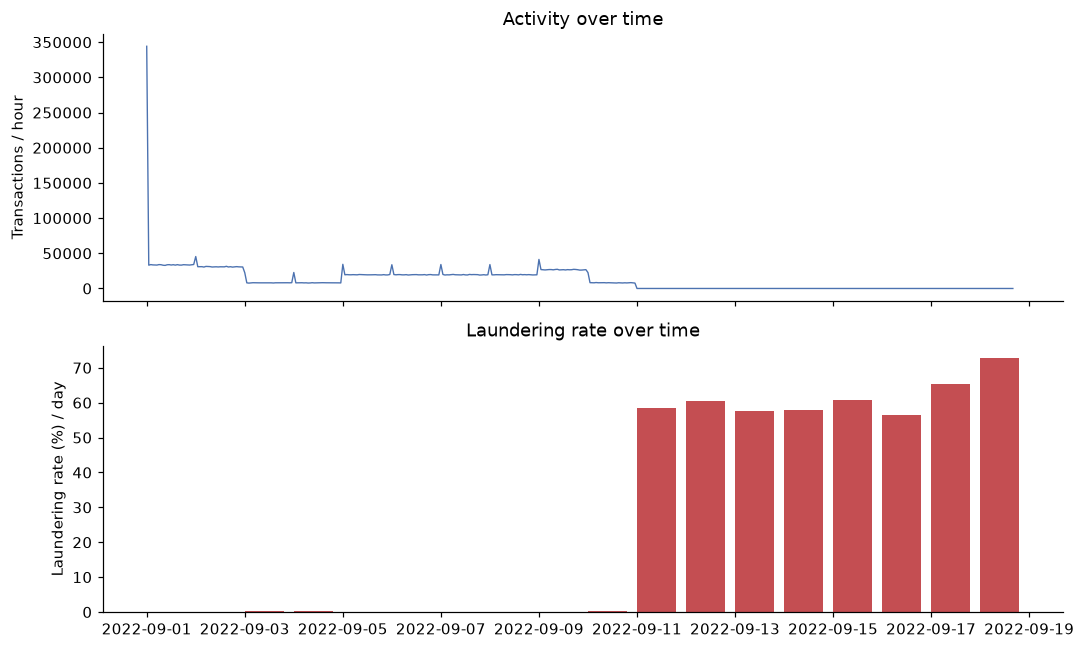

,d,n,ill,rate_pct
0,2022-09-01,1114921,322.0,0.028881
1,2022-09-02,754449,408.0,0.054079
2,2022-09-03,207382,391.0,0.188541
3,2022-09-04,207430,407.0,0.196211
4,2022-09-05,482650,471.0,0.097586
5,2022-09-06,482089,531.0,0.110146
6,2022-09-07,482751,497.0,0.102952
7,2022-09-08,482773,539.0,0.111647
8,2022-09-09,654467,514.0,0.078537
9,2022-09-10,208325,442.0,0.212168


In [8]:
hourly = q(f"""SELECT date_trunc('hour', timestamp) AS h, count(*) n FROM '{P}' GROUP BY 1 ORDER BY 1""")
daily = q(f"""SELECT date_trunc('day', timestamp) AS d, count(*) n, sum(is_laundering) ill,
              100.0*avg(is_laundering) AS rate_pct FROM '{P}' GROUP BY 1 ORDER BY 1""")
daily.to_csv(TAB / "eda_daily.csv", index=False)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(hourly.h, hourly.n, color=LICIT, lw=0.9); axes[0].set_ylabel("Transactions / hour")
axes[0].set_title("Activity over time")
axes[1].bar(daily.d, daily.rate_pct, width=0.8, color=ILLICIT, align="edge")
axes[1].set_ylabel("Laundering rate (%) / day"); axes[1].set_title("Laundering rate over time")
save(fig, "eda_activity_over_time")
daily

## Self-loops

In [9]:
sl = q(f"""SELECT is_laundering, sum(is_self_loop::INT) AS self_loops, count(*) n,
           sum(is_self_loop::INT) FILTER (WHERE payment_format='Reinvestment') AS reinvestment
           FROM '{P}' GROUP BY 1 ORDER BY 1""")
sl.to_csv(TAB / "eda_self_loops.csv", index=False)
sl

,is_laundering,self_loops,n,reinvestment
0,0,591201.0,5073168,481056.0
1,1,11.0,5177,NaN


## Typologies in the patterns file

Matched 3209/3209 pattern rows; 3209 of 5177 laundering txns (62.0%) are in a listed attempt


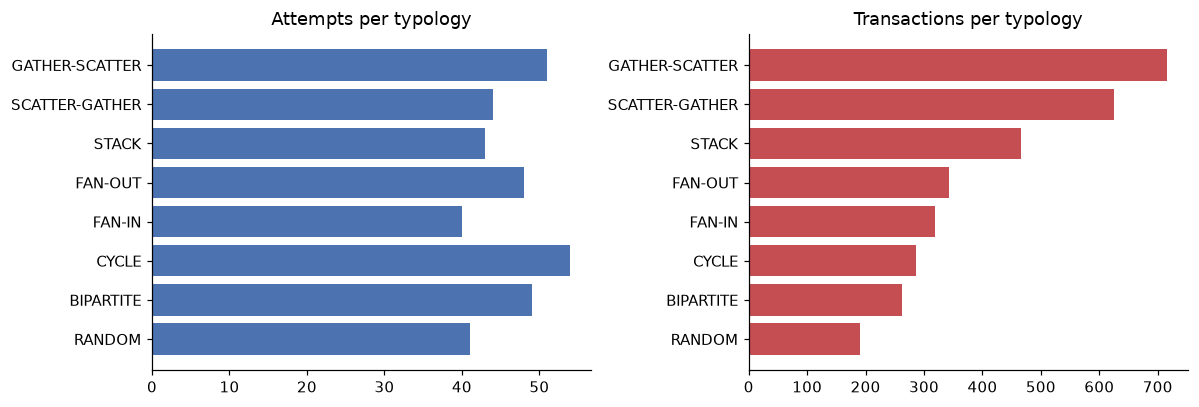

,attempts,transactions,txns_per_attempt
typology,,,
GATHER-SCATTER,51,716,14.039216
SCATTER-GATHER,44,626,14.227273
STACK,43,466,10.837209
FAN-OUT,48,342,7.125000
FAN-IN,40,318,7.950000
CYCLE,54,287,5.314815
BIPARTITE,49,263,5.367347
RANDOM,41,191,4.658537


In [10]:
pat = pd.read_parquet(cfg.root / cfg.paths.processed_dir / "patterns.parquet")
typ = pat.groupby("typology").agg(attempts=("attempt_id", "nunique"), transactions=("seq", "size"))
typ["txns_per_attempt"] = typ.transactions / typ.attempts
typ = typ.sort_values("transactions", ascending=False)
typ.to_csv(TAB / "eda_typologies.csv")
n_ill = int(bal.loc[bal.is_laundering == 1, "n"].iloc[0])
print(f"Matched {pat.txn_id.notna().sum()}/{len(pat)} pattern rows; "
      f"{pat.txn_id.nunique()} of {n_ill} laundering txns ({100*pat.txn_id.nunique()/n_ill:.1f}%) are in a listed attempt")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(typ.index[::-1], typ.attempts[::-1], color=LICIT); axes[0].set_title("Attempts per typology")
axes[1].barh(typ.index[::-1], typ.transactions[::-1], color=ILLICIT); axes[1].set_title("Transactions per typology")
save(fig, "eda_typologies")
typ